In [1]:
# STANDIN A0
# Load the data, the split and the shared helpers (parts/00_setup.ipynb). Dropped from the hand-in
# notebook, where the setup cells come first.
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15
score() and score_proba() ready


Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches
Setup complete: 22 shared names ready in 52 s


In [2]:
# STANDIN B2
# The Part B black box with the settings chosen on validation in B2 (parts/10_baseline_models.ipynb).
# Dropped from the hand-in notebook, where the real B2 cell comes first.
from sklearn.ensemble import HistGradientBoostingClassifier

BOOST_SETTINGS = {"learning_rate": 0.1, "max_leaf_nodes": 31, "random_state": SEED}
def make_boost():
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)

boost = make_boost().fit(X_train, y_train)

<!-- STEP D1 -->
## Part D: global explanation with SHAP

**What SHAP does.** For one flow, SHAP splits the model's output into one contribution per feature:
"`Fwd Seg Size Min` pushed this flow towards *attack* by 2.1, `Bwd Packets/s` pushed it towards *benign*
by 0.4, ...". The contributions add up exactly to the model's output for that flow, starting from a
*base value* (the model's average output). Averaging the size of each feature's contributions over many
flows gives a **global ranking**: which features the model relies on most.

**For gradient boosting the unit is log-odds**, not probability: 0 means 50% attack, +2 about 88%, −2
about 12%. Larger in absolute value means a stronger push. We use `TreeExplainer`, the exact and fast SHAP
method for tree models.

**Which flows.** 1,000 random flows of the **validation** set (seed 42). Part F picks its two features
from this ranking, and choosing anything must not look at the test set.

The feature meanings come from the glossary written in step T4 (`results/tables/T4_feature_glossary.csv`).

In [3]:
# STEP D1
import sys

import matplotlib.pyplot as plt
import shap

sys.path.insert(0, "src")
import xai_tools  # noqa: E402  SHAP/LIME helpers from Lab 3 (src/xai_tools.py)

GLOSSARY = pd.read_csv(TABLES / "T4_feature_glossary.csv", index_col="feature")

EXPLAIN_VAL = X_val.sample(1000, random_state=SEED)          # 1,000 random validation flows
explainer = shap.TreeExplainer(boost)
sv = explainer(EXPLAIN_VAL)
assert sv.values.shape == (1000, len(FEATURES)), sv.values.shape

# Check that the contributions add up: base value + sum of SHAP values = the model's log-odds output.
assert np.allclose(sv.base_values + sv.values.sum(axis=1), boost.decision_function(EXPLAIN_VAL), atol=1e-6)
# The base value is the model's average output in log-odds. It is not the average probability:
# benign flows get very negative log-odds and pull the average far below 0.
print(f"Base value (average model output): {float(np.mean(sv.base_values)):.2f} log-odds")
print(f"The 1,000 flows: {int(y_val.loc[EXPLAIN_VAL.index].sum())} attacks, "
      f"{int((y_val.loc[EXPLAIN_VAL.index] == 0).sum())} benign")

shap_global = (pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
               .sort_values(ascending=False))
top = pd.DataFrame({"mean_abs_shap": shap_global,
                    "share_of_total": shap_global / shap_global.sum()}).head(10)
top["cumulative_share"] = top["share_of_total"].cumsum()
top = top.join(GLOSSARY[["meaning", "direction", "group_proposed"]])
top.index.name = "feature"
top.to_csv(TABLES / "D1_shap_top.csv", float_format="%.4f")
top.style.format({"mean_abs_shap": "{:.3f}", "share_of_total": "{:.1%}", "cumulative_share": "{:.1%}"})

Base value (average model output): -6.73 log-odds
The 1,000 flows: 260 attacks, 740 benign


,mean_abs_shap,share_of_total,cumulative_share,meaning,direction,group_proposed
feature,,,,,,
Fwd Seg Size Min,3.614,42.0%,42.0%,Smallest header size seen in the initiator's packets; depends on the initiator's operating system and TCP options,forward,Free
FWD Init Win Bytes,1.842,21.4%,63.4%,TCP window size in the initiator's first packet: how much data it accepts at once. Set by the initiator's operating system (0 = not TCP or not recorded),forward,Free
Bwd Packets/s,1.113,12.9%,76.4%,How fast the responder sent packets,backward,Fixed
Total Length of Bwd Packet,0.265,3.1%,79.4%,Total payload bytes the responder sent back,backward,Fixed
Packet Length Max,0.183,2.1%,81.6%,"Largest packet payload in the conversation, either direction",both,Fixed
Bwd Packet Length Min,0.170,2.0%,83.5%,Smallest packet payload the responder sent,backward,Fixed
Flow Bytes/s,0.127,1.5%,85.0%,Data rate of the whole conversation (bytes / duration),both,Fixed
Bwd Packet Length Mean,0.095,1.1%,86.1%,Average packet payload the responder sent,backward,Fixed
Packet Length Mean,0.090,1.0%,87.2%,"Average packet payload, both directions together",both,Fixed


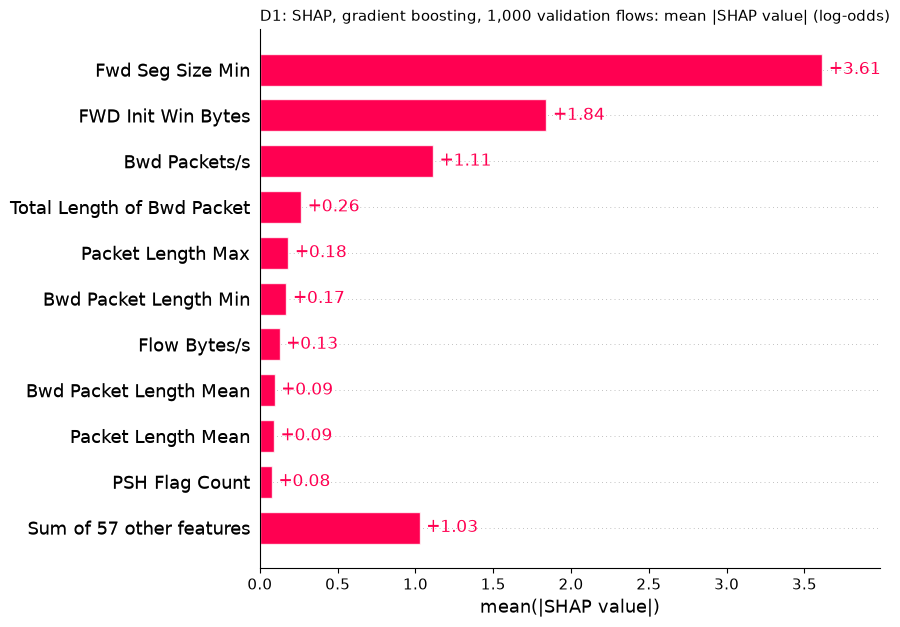

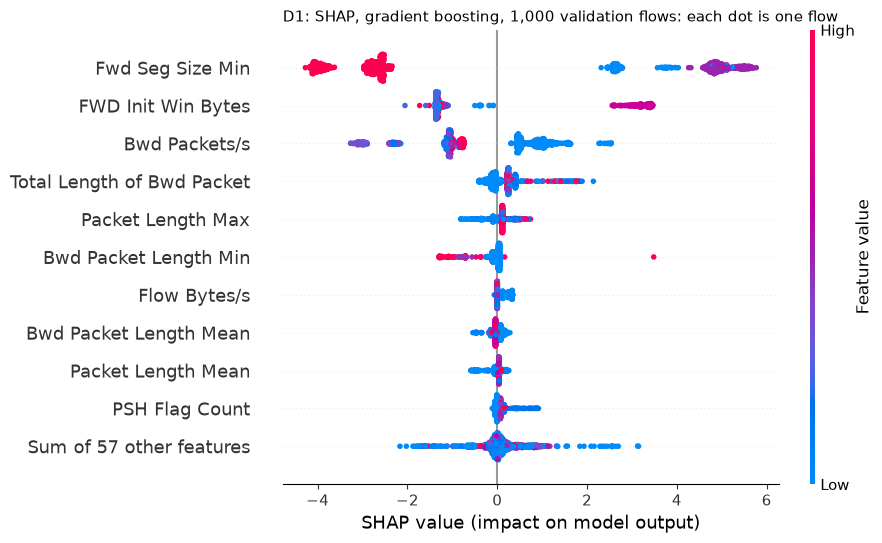

In [4]:
# STEP D1
# Bar plot: average size of each feature's contribution. Beeswarm: one dot per flow, coloured by the
# feature's value (red = high, blue = low); dots to the right push towards "attack".
shap.plots.bar(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: mean |SHAP value| (log-odds)",
          loc="left", fontsize=11)
plt.savefig(FIGURES / "D1_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: each dot is one flow", loc="left",
          fontsize=11)
plt.savefig(FIGURES / "D1_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

<!-- STEP D1 -->
### What the global SHAP picture shows

**Three features carry three quarters of the model's reasoning.** `Fwd Seg Size Min` (42% of the total
SHAP weight), `FWD Init Win Bytes` (21%) and `Bwd Packets/s` (13%) together account for 76%; the other
64 features share the rest. (The base value, the model's average output, is −6.7 log-odds; that every
contribution adds up exactly to the model's output is checked in the code.)

**The top two describe the attacker's machine, not the attack.** Both are TCP settings that the operating
system of the initiating computer chooses when it opens a connection. In the training data:

| Value | Training flows | Share that are attacks |
|---|---:|---:|
| `Fwd Seg Size Min` = 20 bytes | 51,301 | 89% |
| `Fwd Seg Size Min` = 32 bytes | 106,150 | 0% |
| `FWD Init Win Bytes` = 16,383 | 50,987 | 90% |
| `FWD Init Win Bytes` = 5,792 | 87,434 | 0% |

95% of all training attacks (45,841 of 48,155) open their connection with a window of exactly 16,383 bytes.
In the beeswarm this shows as two well-separated clouds per feature: one value pushes strongly towards
"attack", the other strongly towards "benign". In UNSW-NB15 all attacks were generated by a few attacker
machines with their own TCP settings, while the normal traffic came from other machines. The model has
learned to **recognise those machines**: a *shortcut* that works on this dataset but says nothing about
what an attack does.

**Do the features make sense to a security person? Only partly.**
- `Fwd Seg Size Min` and `FWD Init Win Bytes`: no, not as evidence of an attack. They are a fingerprint of
  the machine. An attacker using another operating system, or changing two TCP settings on their own
  machine, would no longer look like this, and a normal computer that happens to share these settings
  would look like an attacker. A security person would use them to recognise *known* machines, not
  attacks in general.
- `Bwd Packets/s` (how fast the other side replies), `Total Length of Bwd Packet`, `Packet Length Max`,
  `Bwd Packet Length Min` and `Flow Bytes/s`: yes. They describe the conversation itself: scans and
  floods get few or no replies from the victim, exploits and fuzzing send unusual packet sizes. These are
  the kind of evidence an analyst would look at.

This shortcut is the most important finding of Part D. It explains why the models in Part B are so
accurate, it is what an attacker could fake most cheaply (step E4), and it reappears in Parts F and G.
The optional extra X6 tests how well the model does without the TCP-settings features.

<!-- STEP D2 -->
## Part D: three flows to explain

The brief asks for three local explanations: **a confident correct detection, a confident correct
negative, and a mistake**. We pick them from the **test** set with the black box's attack probability:

- **detection**: the true attack with the highest attack probability;
- **negative**: the true benign flow with the lowest attack probability;
- **mistake**: the wrongly classified flow the model was most sure about (probability furthest from 0.5).
  It can be a false alarm (benign called attack) or a missed attack.

When several flows tie (many get a probability of practically 1 or 0), the first one in test-set order is
taken, so the choice is reproducible. Explaining test flows is allowed: it changes no model or setting.
The positions are stored in `CASES` and used by D3–D6 and by Part F.

In [5]:
# STEP D2
p_test = boost.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(int)
y_true = y_test.to_numpy()

caught = np.flatnonzero((y_true == 1) & (pred_test == 1))
cleared = np.flatnonzero((y_true == 0) & (pred_test == 0))
wrong = np.flatnonzero(pred_test != y_true)

# argmax / argmin return the first position on a tie (test-set order), so the choice is reproducible.
CASES = {"detection": int(caught[np.argmax(p_test[caught])]),
         "negative": int(cleared[np.argmin(p_test[cleared])]),
         "mistake": int(wrong[np.argmax(np.abs(p_test[wrong] - 0.5))])}

print(f"Test flows: {len(caught):,} correct detections, {len(cleared):,} correct negatives, "
      f"{len(wrong):,} mistakes ({int((y_true[wrong] == 0).sum()):,} false alarms, "
      f"{int((y_true[wrong] == 1).sum()):,} missed attacks)")
print(f"Ties: {int((p_test[caught] == p_test[caught].max()).sum())} detections share the highest "
      f"probability, {int((p_test[cleared] == p_test[cleared].min()).sum())} negatives the lowest")

TOP3 = list(shap_global.index[:3])
cases = pd.DataFrame([{
    "case": name, "test_position": pos, "attack_type": type_test.iloc[pos],
    "true_label": "attack" if y_true[pos] == 1 else "benign",
    "called": "attack" if pred_test[pos] == 1 else "benign",
    "attack_probability": p_test[pos],
    **{f: X_test.iloc[pos][f] for f in TOP3},
} for name, pos in CASES.items()]).set_index("case")
cases.to_csv(TABLES / "D2_cases.csv", float_format="%.6g")
cases

Test flows: 15,928 correct detections, 43,728 correct negatives, 1,365 mistakes (1,241 false alarms, 124 missed attacks)
Ties: 1 detections share the highest probability, 1 negatives the lowest


,test_position,attack_type,true_label,called,attack_probability,Fwd Seg Size Min,FWD Init Win Bytes,Bwd Packets/s
case,,,,,,,,
detection,50065,Exploits,attack,attack,9.995756e-01,20.0,16383.0,22.675749
negative,47114,Benign,benign,benign,2.061596e-07,8.0,0.0,2006.018054
mistake,10048,Benign,benign,attack,9.989081e-01,20.0,16383.0,23.214244


In [6]:
# STEP D2
# How much of the model's behaviour on the test set follows the attacker fingerprint
# (Fwd Seg Size Min = 20 and FWD Init Win Bytes = 16,383, see D1)?
fingerprint = ((X_test["Fwd Seg Size Min"] == 20) & (X_test["FWD Init Win Bytes"] == 16383)).to_numpy()
false_alarm = (y_true == 0) & (pred_test == 1)
missed = (y_true == 1) & (pred_test == 0)
fp_check = pd.DataFrame({
    "flows": [int((fingerprint & (y_true == 1)).sum()), int((fingerprint & (y_true == 0)).sum()),
              int((~fingerprint & (y_true == 1)).sum()), int((~fingerprint & (y_true == 0)).sum())],
    "called attack": [float(pred_test[fingerprint & (y_true == 1)].mean()),
                      float(pred_test[fingerprint & (y_true == 0)].mean()),
                      float(pred_test[~fingerprint & (y_true == 1)].mean()),
                      float(pred_test[~fingerprint & (y_true == 0)].mean())],
}, index=pd.MultiIndex.from_tuples([("fingerprint", "attack"), ("fingerprint", "benign"),
                                    ("no fingerprint", "attack"), ("no fingerprint", "benign")],
                                   names=["test flows with", "true label"]))
fp_check.to_csv(TABLES / "D2_fingerprint_check.csv", float_format="%.4f")
print(f"False alarms with the fingerprint: {int((false_alarm & fingerprint).sum()):,} of {int(false_alarm.sum()):,}")
print(f"Missed attacks without the fingerprint: {int((missed & ~fingerprint).sum()):,} of {int(missed.sum()):,}")
fp_check.style.format({"flows": "{:,}", "called attack": "{:.1%}"})

False alarms with the fingerprint: 1,197 of 1,241
Missed attacks without the fingerprint: 4 of 124


<!-- STEP D2 -->
### The three flows and what they already show

| Case | Test position | Type | Called | Attack probability | `Fwd Seg Size Min` | `FWD Init Win Bytes` | `Bwd Packets/s` |
|---|---:|---|---|---:|---:|---:|---:|
| detection | 50,065 | Exploits | attack | 0.9996 | 20 | 16,383 | 22.7 |
| negative | 47,114 | Benign | benign | 0.0000002 | 8 | 0 | 2,006 |
| mistake | 10,048 | **Benign** | **attack** | 0.9989 | 20 | 16,383 | 23.2 |

**The mistake is a false alarm that looks exactly like the detection** on the three most important
features: the same attacker fingerprint (`Fwd Seg Size Min` = 20, `FWD Init Win Bytes` = 16,383) and
almost the same reply rate. The model is 99.9% sure it is an attack. The negative has a completely
different profile (no TCP window at all, which usually means the flow is not a TCP connection, and a fast
reply rate). D3 explains all three with SHAP and LIME.

**The fingerprint explains almost all false alarms** (second table above):
- **1,197 of the 1,241 false alarms (96%)** are benign flows with the attacker fingerprint. Of the 1,731
  benign test flows that carry it, 69% are called attacks; of the 43,238 benign flows without it, only
  0.1%. These benign flows probably come from the same kind of machines as the attacks (in the full
  recording, 1.6% of benign flows come from the attacker addresses), so the model cannot tell them apart.
- **The model is not *only* the fingerprint.** The 749 attacks without it are still caught 99.5% of the
  time, through the behaviour features (reply rate, packet sizes). And 120 of the 124 missed attacks *do*
  carry the fingerprint: among fingerprint flows, the behaviour features decide, and that is where both
  kinds of mistake happen.

So the fingerprint sorts flows into "attacker-like machine" or not, and within the attacker-like group the
behaviour features do the fine work. A benign computer that shares the attacker's TCP settings is very
likely to be flagged.